In [1]:
import os
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = "......"
model = ChatGroq(model = "qwen/qwen3-32b")

Summarization Middleware

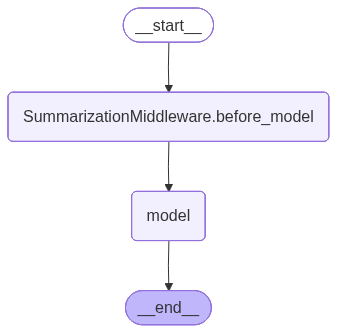

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# agent with messagesbased SummarizationMiddleware
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [ ]:
#thread_id
config={"configurable":{"thread_id":"test1"}}
    

In [4]:
questions=[
    "what is 2+2?",
    "What is 10*5?",
    "what is 100/4?",
    "what is 15-7?",
    "what is 3*3?",
    "what is 4*4?",
    
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages:{response}")
    print(f"Messages:{len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='what is 2+2?', additional_kwargs={}, response_metadata={}, id='eb7f5659-f59b-4e83-997e-41de05f997cd'), AIMessage(content='<think>\nOkay, so the question is "what is 2+2?" Hmm, that seems straightforward, but let me make sure I understand it correctly. The user is asking for the sum of two and two. Let me recall my basic arithmetic. Addition is one of the first operations we learn in math. When you add two numbers, you combine their quantities.\n\nLet me visualize this. If I have two apples and someone gives me two more apples, how many apples do I have in total? That would be 2 + 2. Counting them: one, two, three, four. So four apples. That makes sense. \n\nBut wait, could there be any trick here? Sometimes people ask simple questions to test if you\'re paying attention. Let me think. In standard arithmetic, 2 + 2 is definitely 4. Is there any context where it might be different? In some non-standard systems or in certain languages? For exam

Token Size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.tools import tool

@tool
def search_hotels(city:str) ->str:
    """Search hotels - retrun long response to use more tokens,"""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business centre
    3. Budget stay - 3 star , $75/night, free Wifi"""


agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens",550),
            keep=("tokens",200)
        )
    ]
)    
config={"configurable":{"thread_id":"test1"}}

#token counter
def count_tokens(messages):
    total_chars = sum(len(str(m.content))for m in messages)
    return total_chars//4 #4chars=1token


In [6]:
#Run test 
cities = ["Paris", "New York", "Tokyo", "Landon", "Dubai", "Singapore"]

for city in cities:
    response=agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])}messages")
    print(f"{(response['messages'])}")

Paris: ~182 tokens, 4messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='d1bea3da-0b2f-4336-ab71-3f54e6575987'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to find hotels in Paris. Let me check the available tools. There's a function called search_hotels that takes a city parameter. The city here is Paris. I need to make sure the function is called correctly. The parameters should be a JSON object with the city name. I'll structure the tool call accordingly. Let me confirm the syntax again. The function name is search_hotels, and the argument is the city as a string. Everything looks good. Time to generate the tool call.\n", 'tool_calls': [{'id': 'c75q0gvmj', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 156, 'total_tokens': 286, 'completion_time': 0.239596227, 'completi

Human Middleware

In [7]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware

In [14]:
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID"""
    return f"Email content for ID:{email_id}"

def send_emial_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email"""
    return f"Email sent to {recipient} wth subject '{subject}'"

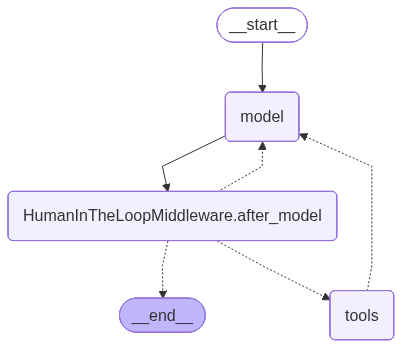

In [15]:
agent = create_agent(
    model = model,
    tools = [read_email_tool,send_emial_tool],
    checkpointer = InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]

)
agent

In [19]:
config = {"configurable": {"thread_id": "test-approve"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to jhon@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [20]:
result

{'messages': [HumanMessage(content="Send email to jhon@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='5596da8f-0d31-4e53-b8be-7bc194ab5e57'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to jhon@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's a send_email_tool that requires recipient, subject, and body. The parameters are all there: recipient is the email address provided, subject is 'Hello', and the body is 'How are you?'. I need to make sure all required fields are included. Yes, they are. So I should call the send_email_tool with these parameters. No other tools are needed here since the user isn't asking to read an email. Just need to structure the JSON correctly for the tool call.\n", 'tool_calls': [{'id': 'n40vv8p8r', 'function': {'arguments': '{"body":"How are you?","recipient":"jhon@test.com","subject":"Hello"}',

In [21]:
from langgraph.types import Command

if "__interrupt__" in result:
    print("Approving")

    result = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approved"}
                ]

            }
        ),
        config=config
    )
    print(f"Result: {result['messgaes'][-1].content}")